In [1]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc

In [2]:
scroot = '/work/users/k/r/kritis/single_cell/PRJNA679579'

In [3]:
X = mmread(f"{scroot}/GSE161824_A549_TP53.processed.matrix.mtx").tocsr()

In [4]:
# Load gene names and barcodes
genes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.genes.csv", header=None)
barcodes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.cells.csv", header=None)

In [5]:
import anndata as ad
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [6]:
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224


In [10]:
barcodes_mut = pd.read_csv('/work/users/k/r/kritis/database_analysis/TP53_example/DICER1_barcodes.csv')

In [11]:
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [12]:
adata.obs['mut'] = adata.obs_names.isin(barcode_list)
# Optional: make it clearer
adata.obs['mut'] = adata.obs['mut'].map({True: 'Target', False: 'Other'})

In [13]:
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()

In [15]:
genes = pd.read_csv('/work/users/k/r/kritis/single_cell/PRJNA679579/TP53_DICER1_example/genelist.csv')

In [16]:
gene_list = genes['0'].tolist()

In [17]:
gene_list = [g for g in gene_list if g in adata.var_names]
print(f"Using {len(gene_list)} genes from your list.")

Using 6 genes from your list.


In [18]:
gene_list

['SCD', 'NCOA7', 'GADD45A', 'ILF2', 'MT-ND6', 'ANG']

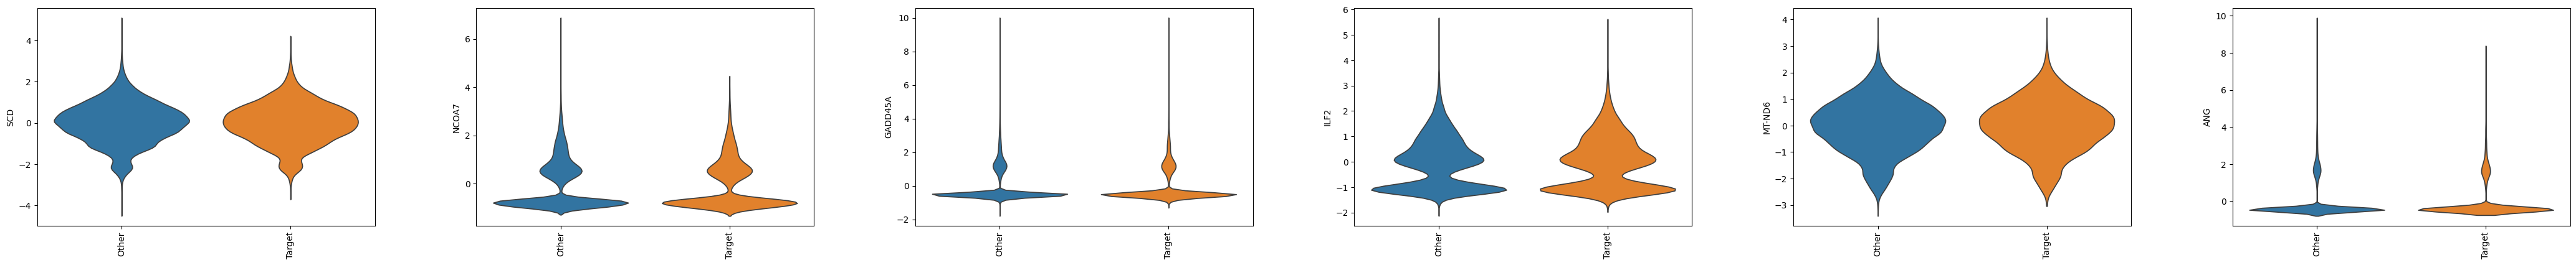

In [19]:
sc.pl.violin(adata, keys=gene_list, groupby='mut', stripplot=False, jitter=False, rotation=90)

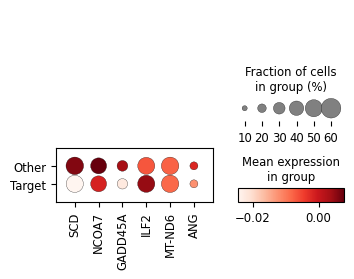

In [20]:
sc.pl.dotplot(adata, var_names=gene_list, groupby='mut')

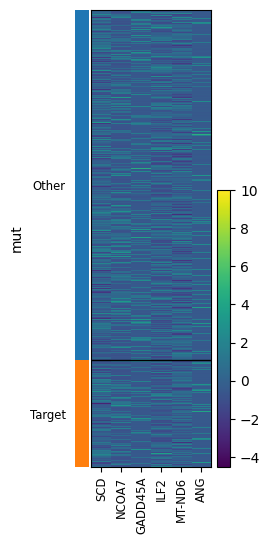

In [21]:
sc.pl.heatmap(adata, var_names=gene_list, groupby='mut', use_raw=False)

In [22]:
import numpy as np

# Convert sparse to dense if needed
X = adata[:, gene_list].X.toarray() if not isinstance(adata.X, np.ndarray) else adata[:, gene_list].X

# Create a DataFrame of expression values
import pandas as pd
expr_df = pd.DataFrame(X, columns=gene_list, index=adata.obs_names)
expr_df['mut'] = adata.obs['mut'].values

# Group by 'Target' and 'Other' and compute mean expression
signature_stats = expr_df.groupby('mut').mean()
print(signature_stats)

             SCD     NCOA7   GADD45A      ILF2    MT-ND6       ANG
mut                                                               
Other   0.005924  0.007745  0.003335 -0.006776 -0.007727 -0.002051
Target -0.024624 -0.001526 -0.022310  0.004696 -0.008276 -0.012313


/tmp/ipykernel_3427414/1533957719.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_stats = expr_df.groupby('mut').mean()


In [23]:
gene_set = [g for g in gene_list if g in adata_target.var_names]

# All other genes
other_genes = [g for g in adata_target.var_names if g not in gene_set]

In [24]:
gene_idx = [adata_target.var_names.get_loc(g) for g in gene_set]
other_idx = [i for i in range(adata_target.shape[1]) if i not in gene_idx]

In [25]:
X = adata_target.X.toarray() if not isinstance(adata_target.X, np.ndarray) else adata_target.X

# Compute per-cell mean expression
sig_expr = X[:, gene_idx].mean(axis=1)
other_expr = X[:, other_idx].mean(axis=1)

/tmp/ipykernel_3427414/1962594932.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gene Set', y='Average Expression', data=df_long, inner='box', palette='pastel')


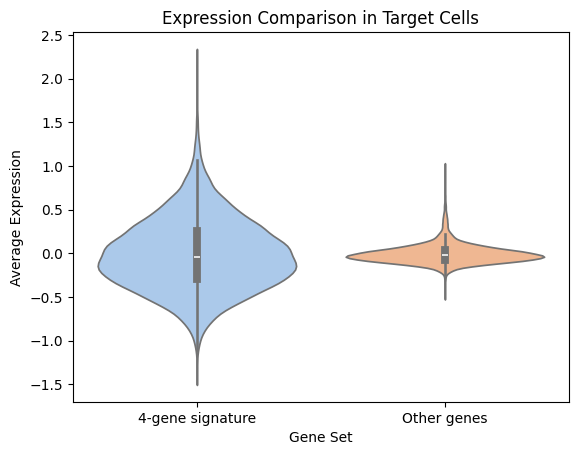

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tidy DataFrame
df_long = pd.DataFrame({
    '4-gene signature': sig_expr,
    'Other genes': other_expr
}).melt(var_name='Gene Set', value_name='Average Expression')

# Plot
sns.violinplot(x='Gene Set', y='Average Expression', data=df_long, inner='box', palette='pastel')
plt.title("Expression Comparison in Target Cells")
plt.show()

In [27]:
from scipy.stats import wilcoxon

stat, pval = wilcoxon(sig_expr, other_expr)
print(f"Wilcoxon signed-rank test p-value: {pval:.3e}")

Wilcoxon signed-rank test p-value: 9.584e-12
